In [16]:
import numpy as np
import rebound as rb
import einsteinpy.symbolic as es    
import scipy as sp 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

1. Sistema de Unidades Geometrizadas
Para simplificar el cálculo numérico de las geodésicas y evitar inconsistencias de escala, adoptamos el sistema de unidades geometrizadas, en el cual se define:

$$G = c = 1$$Bajo este sistema, la masa $M$ del agujero negro define las escalas fundamentales de longitud y tiempo del problema. La Unidad de Longitud ($UL$) corresponde al radio gravitacional:$$1 \text{ UL} = \frac{GM}{c^2}$$De igual manera, la Unidad de Tiempo ($UT$) se define como el tiempo que tarda la luz en recorrer dicha distancia:$$1 \text{ UT} = \frac{UL}{c} = \frac{GM}{c^3}$$En estas unidades, el Radio de Schwarzschild para un agujero negro estático viene dado por $R_s = 2M$.

In [17]:
# Definimos unidades basadas en un agujero negro de masa solar (M=1)
c = 1.0  # Velocidad de la luz [6]
G = 1.0  # Constante de gravitación [4]
M = 1.0  # Masa del objeto central

# Unidad de longitud (UL) = Radio gravitacional (GM/c^2)
UL = G * M / c**2 
# Unidad de tiempo (UT) = UL / c
UT = UL / c 

Geodésicas en el Límite Newtoniano (Campo Débil)Para establecer una base comparativa con los efectos relativistas puros, modelamos el comportamiento de las partículas mediante una métrica de campo débil (aproximación Newtoniana), donde el tensor métrico adopta la forma:$$ds^2 = -\left(1 - \frac{2GM}{c^2r}\right)c^2dt^2 + dx^2 + dy^2 + dz^2$$Utilizando la ecuación de la geodésica $\frac{dU^\mu}{d\tau} + \Gamma^\mu_{\alpha\beta}U^\alpha U^\beta = 0$, deducimos los símbolos de Christoffel relevantes para el movimiento. La evolución temporal del factor de Lorentz de la partícula ($U^t$) queda determinada por:$$\frac{dU^t}{d\tau} = -\frac{2GM U^t}{r^2(c^2r - 2GM)} (xU^x + yU^y + zU^z)$$Mientras que para las componentes espaciales, en el límite clásico donde el espacio no está curvado, la aceleración se reduce a la fuerza gravitacional Newtoniana por unidad de masa:$$\frac{dU^i}{d\tau} = -\frac{GM}{r^3}x^i$$

In [18]:
import numpy as np  # Asegúrate de tener importado numpy antes

def edg_newton(tau, Ys, G, M, c):
    """
    Ecuaciones diferenciales para la trayectoria en el límite Newtoniano/Campo Débil.
    Ys contiene: [T, x, y, z, Ut, Ux, Uy, Uz]
    """
    T, x, y, z, Ut, Ux, Uy, Uz = Ys
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # Evitar división por cero si la partícula cae al centro
    if r < 1e-5:
        return [0]*8
    
    # 1. Derivadas de las coordenadas (Cuadrivelocidad)
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz
    
    # 2. Componente temporal: dUt/dtau
    # Denominador correcto para la métrica de campo débil
    denom = (c**2 * r - 2 * G * M) * r**2
    dUt_dtau = -2 * G * M * Ut * (x*Ux + y*Uy + z*Uz) / denom
    
    # 3. Componentes espaciales: dUi/dtau
    # En el límite de campo débil, la aceleración recupera la ley de Newton modificada por Ut
    factor_espacial = -(G * M / r**3)
    dUx_dtau = factor_espacial * x
    dUy_dtau = factor_espacial * y
    dUz_dtau = factor_espacial * z
    
    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

Determinación de las Condiciones Iniciales y NormalizaciónPara iniciar la integración numérica de las geodésicas, es fundamental que el vector de estado inicial cumpla con la restricción de normalización de la cuadrivelocidad para partículas con masa, definida por el invariante:$$g_{\mu\nu} U^\mu U^\nu = -c^2$$Dado que conocemos la posición inicial $r_0 = 10 \text{ UL}$ y la velocidad espacial tridimensional respecto al tiempo coordenado $\vec{v} = (v^x, v^y, v^z)$, relacionamos la cuadrivelocidad con la velocidad tridimensional mediante $U^i = U^t v^i$. Sustituyendo esto en la condición de normalización para una métrica espacialmente plana:$$g_{00} (U^t)^2 + \delta_{ij} (U^t v^i)(U^t v^j) = -c^2$$Despejando el componente temporal $U^t$ obtenemos la ecuación que garantiza condiciones iniciales físicamente consistentes:$$U^t_0 = \sqrt{\frac{-c^2}{g_{00} + |\vec{v}|^2}}$$

In [19]:
# --- CONDICIONES INICIALES ---
t0 = 0.0
# Colocamos la partícula a 10 unidades de longitud (fuera del horizonte)
x0, y0, z0 = 10.0, 0.0, 0.0
r0 = np.sqrt(x0**2 + y0**2 + z0**2)

# Velocidad de coordenadas inicial (fracción de c)
vx0, vy0, vz0 = 0.0, 0.25, 0.0 
v_sq = vx0**2 + vy0**2 + vz0**2

# Coeficientes métricos iniciales (Signatura -, +, +, +)
g00 = -(1.0 - (2.0 * G * M) / (c**2 * r0))
# Las componentes espaciales en la métrica newtoniana son planas (+1)
g11 = g22 = g33 = 1.0  

# Cálculo de Ut inicial mediante la normalización: g_un U^u U^v = -c^2
# Desarrollando: g00*(Ut)^2 + g_ii*(vi*Ut)^2 = -c^2  => Ut = sqrt(-c^2 / (g00 + v_sq))
Ut0 = np.sqrt(-(c**2) / (g00 + v_sq))

# Transformamos las velocidades de coordenadas a componentes de la cuadrivelocidad (U = v * Ut)
Ux0 = vx0 * Ut0
Uy0 = vy0 * Ut0
Uz0 = vz0 * Ut0

# Vector de estado inicial para el integrador: [T, x, y, z, Ut, Ux, Uy, Uz]
Y0 = [c * t0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]

 Integración Numérica de las Ecuaciones GeodésicasLa evolución del vector de estado de la partícula se obtiene mediante la integración del sistema de ocho ecuaciones diferenciales ordinarias de primer orden simultáneas. La variable independiente de integración es el tiempo propio $\tau$:$$\tau \in [0, \tau_{\text{final}}]$$Se utiliza el algoritmo implícito de Radau (un método Runge-Kutta implícito de la familia RADAU IIA) debido a su excelente estabilidad numérica y su capacidad para resolver sistemas rígidos (stiff), condiciones comunes cuando las partículas se aproximan a regiones de fuerte curvatura espacio-temporal. Para evitar la acumulación de errores numéricos y asegurar la conservación del momento angular y la energía de la órbita, se imponen tolerancias estrictas de convergencia:$$\text{rtol} = 10^{-9}, \quad \text{atol} = 10^{-12}$$

In [20]:
from scipy.integrate import solve_ivp  # Asegúrate de importar la función

# Intervalo de integración en términos de Tiempo Propio (tau)
tau_final = 500.0
taus = np.linspace(0, tau_final, 2000)

# Ejecución del integrador con altas tolerancias de precisión para conservar la energía de la órbita
solucion = solve_ivp(
    edg_newton, 
    [0.0, tau_final], 
    Y0, 
    args=(G, M, c), 
    t_eval=taus, 
    method='Radau',
    rtol=1e-9,   # Tolerancia relativa estricta
    atol=1e-12   # Tolerancia absoluta estricta
)

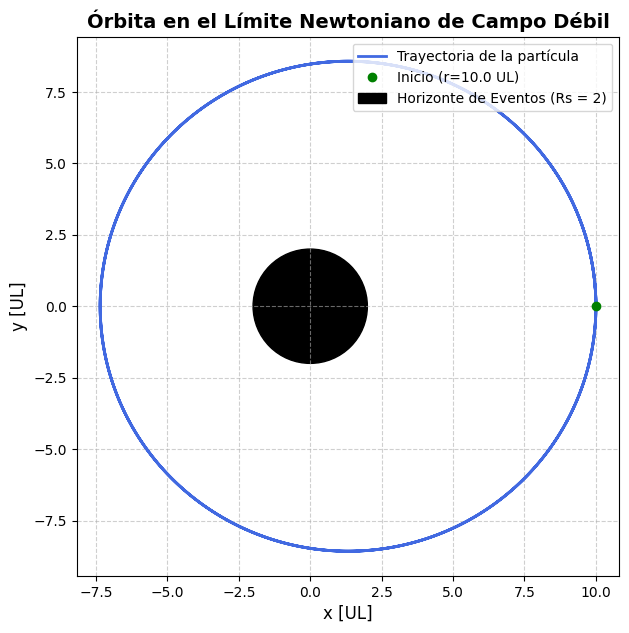

In [21]:
import matplotlib.pyplot as plt

# --- EXTRACCIÓN CORRECTA DE RESULTADOS ---
# Mapeo correcto según el orden del vector de estado: [T, x, y, z, Ut, Ux, Uy, Uz]
ts = solucion.y[0] / c  # Índice 0: Tiempo del observador (T = c*t)
xs = solucion.y[1]      # Índice 1: Coordenada x
ys = solucion.y[2]      # Índice 2: Coordenada y
zs = solucion.y[3]      # Índice 3: Coordenada z

# --- GRAFICACIÓN ---
plt.figure(figsize=(7, 7))

# Dibujamos la trayectoria de la partícula
plt.plot(xs, ys, color='royalblue', linewidth=2, label='Trayectoria de la partícula')
# Marcamos el punto de inicio
plt.plot(xs[0], ys[0], 'go', label=f'Inicio (r={xs[0]} UL)')

# Dibujamos el Agujero Negro en el centro como referencia (Radio de Schwarzschild = 2*G*M/c^2 = 2.0)
radio_horizonte = 2.0 * G * M / (c**2)
circulo_horizonte = plt.Circle((0, 0), radio_horizonte, color='black', label='Horizonte de Eventos (Rs = 2)')
plt.gca().add_patch(circulo_horizonte)

# Configuraciones estéticas de la gráfica
plt.xlabel('x [UL]', fontsize=12)
plt.ylabel('y [UL]', fontsize=12)
plt.title('Órbita en el Límite Newtoniano de Campo Débil', fontsize=14, fontweight='bold')
plt.axis('equal') # Crucial para que la órbita no se vea deformada o elíptica artificialmente
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

In [30]:
# --- SIMULACIÓN MULTI-PARTÍCULA EN 3D ---
num_particulas = 500  # Aumentamos un poco para que se aprecie mejor el volumen
tau_final = 400.0
taus = np.linspace(0, tau_final, 1000)

resultados_disco_3d = []
np.random.seed(42)

for i in range(num_particulas):
    r_ini = np.random.uniform(6.0, 15.0)
    theta = np.random.uniform(0, 2 * np.pi)
    
    # Añadimos una pequeña variación en Z para que el disco no sea perfectamente plano
    # Simula el grosor real de un disco de acreción hidrodinámico
    xi = r_ini * np.cos(theta)
    yi = r_ini * np.sin(theta)
    zi = np.random.uniform(-0.5, 0.5)  # Pequeño grosor en el eje Z
    
    v_mag = np.sqrt((G * M) / r_ini)
    
    # Velocidades tangenciales con una leve perturbación en Vz
    vxi = -v_mag * np.sin(theta)
    vyi = v_mag * np.cos(theta)
    vzi = np.random.uniform(-0.02, 0.02) # Pequeña velocidad vertical
    
    # --- NORMALIZACIÓN RELATIVISTA DE UT0 ---
    r_3d = np.sqrt(xi**2 + yi**2 + zi**2)
    g00_i = -(1.0 - (2.0 * G * M) / (c**2 * r_3d))
    v_sq_i = vxi**2 + vyi**2 + vzi**2
    Ut0_i = np.sqrt(-(c**2) / (g00_i + v_sq_i))
    
    Uxi = vxi * Ut0_i
    Uyi = vyi * Ut0_i
    Uzi = vzi * Ut0_i
    
    Y0_i = [0.0, xi, yi, zi, Ut0_i, Uxi, Uyi, Uzi]
    
    sol = solve_ivp(
        edg_newton, 
        [0.0, tau_final], 
        Y0_i, 
        args=(G, M, c), 
        t_eval=taus, 
        method='Radau',
        rtol=1e-7, 
        atol=1e-9
    )
    
    if sol.success:
        resultados_disco_3d.append(sol.y)

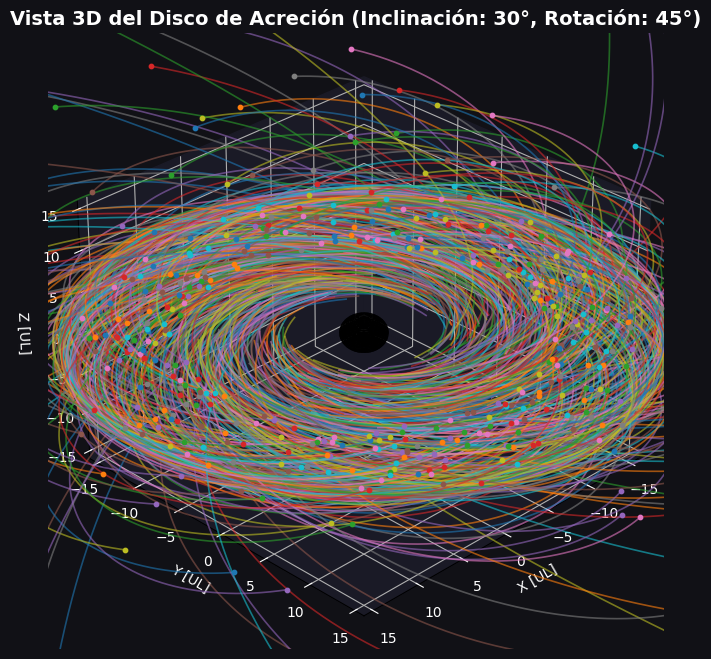

In [32]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- CONFIGURACIÓN DEL ÁNGULO DE VISIÓN ---
# Cambia estos números para ver el disco desde donde tú quieras:
elevacion = 30  # Ángulo de inclinación vertical
azimut = 45     # Ángulo de rotación horizontal
ax.view_init(elev=elevacion, azim=azimut)

# Dibujamos las trayectorias de las partículas en el espacio 3D
for y_particula in resultados_disco_3d:
    x_p = y_particula[1]
    y_p = y_particula[2]
    z_p = y_particula[3]
    
    ax.plot(x_p, y_p, z_p, alpha=0.6, linewidth=1.2)
    ax.scatter(x_p[-1], y_p[-1], z_p[-1], s=10) # Posición final de la partícula

# Dibujamos el Agujero Negro en el centro como una esfera
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', zorder=10)

# Configuración estética del espacio 3D
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

# --- SINTAXIS MODERNA PARA LOS PLANOS DE LOS EJES ---
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales en 3D
lim = 16
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title(f'Vista 3D del Disco de Acreción (Inclinación: {elevacion}°, Rotación: {azimut}°)', 
          color='white', fontsize=14, fontweight='bold')
plt.show()